In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
# upload dataset
df = pd.read_csv("/content/netflix_titles.csv")

df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [6]:
print("Dataset Shape:", df.shape)

Dataset Shape: (8807, 12)


In [7]:
print("\nColumn Names:")
print(df.columns)


Column Names:
Index(['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added',
       'release_year', 'rating', 'duration', 'listed_in', 'description'],
      dtype='object')


In [8]:
print("\nData Types:")
print(df.dtypes)


Data Types:
show_id         object
type            object
title           object
director        object
cast            object
country         object
date_added      object
release_year     int64
rating          object
duration        object
listed_in       object
description     object
dtype: object


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


In [10]:
#Check Missing Values
print("Missing Values in Each Column:\n")
df.isnull().sum()

Missing Values in Each Column:



,0
show_id,0
type,0
title,0
director,2634
cast,825
country,831
date_added,10
release_year,0
rating,4
duration,3


In [11]:
# Handling Missing Values
# Fill categorical columns with 'Unknown'
df['director'].fillna('Unknown', inplace=True)
df['cast'].fillna('Unknown', inplace=True)
df['country'].fillna('Unknown', inplace=True)
df['rating'].fillna('Unknown', inplace=True)



/tmp/ipykernel_333/1752110194.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['director'].fillna('Unknown', inplace=True)
/tmp/ipykernel_333/1752110194.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try usin

In [12]:
# Fill date_added with most frequent value
df['date_added'].fillna(df['date_added'].mode()[0], inplace=True)

/tmp/ipykernel_333/224690223.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['date_added'].fillna(df['date_added'].mode()[0], inplace=True)


In [13]:
# Check again
df.isnull().sum()

,0
show_id,0
type,0
title,0
director,0
cast,0
country,0
date_added,0
release_year,0
rating,0
duration,3


In [15]:
# Remove leading and trailing spaces
df['date_added'] = df['date_added'].str.strip()

# Convert to datetime format
df['date_added'] = pd.to_datetime(df['date_added'], errors='coerce')

df.dtypes

,0
show_id,object
type,object
title,object
director,object
cast,object
country,object
date_added,datetime64[ns]
release_year,int64
rating,object
duration,object


In [16]:
df['date_added'].head()

,date_added
0,2021-09-25
1,2021-09-24
2,2021-09-24
3,2021-09-24
4,2021-09-24


In [17]:
# Remove Duplicate Records
print("Duplicate Rows:", df.duplicated().sum())
df.drop_duplicates(inplace=True)
print("Duplicates After Removal:", df.duplicated().sum())

Duplicate Rows: 0
Duplicates After Removal: 0


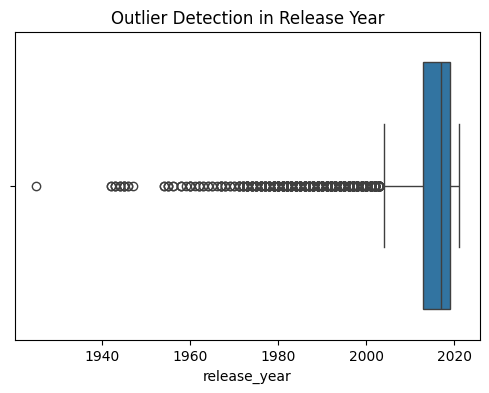

In [18]:
# Detect Outliers
plt.figure(figsize=(6,4))
sns.boxplot(x=df['release_year'])
plt.title("Outlier Detection in Release Year")
plt.show()

In [19]:
# Treat Outliers
Q1 = df['release_year'].quantile(0.25)
Q3 = df['release_year'].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR
df = df[(df['release_year'] >= lower) & (df['release_year'] <= upper)]
print("Outliers removed successfully")

Outliers removed successfully


In [20]:
# Drop Irrelevant Features
df.drop(['show_id', 'description'], axis=1, inplace=True)
df.head()

,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in
0,Movie,Dick Johnson Is Dead,Kirsten Johnson,Unknown,United States,2021-09-25,2020,PG-13,90 min,Documentaries
1,TV Show,Blood & Water,Unknown,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries"
2,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",Unknown,2021-09-24,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act..."
3,TV Show,Jailbirds New Orleans,Unknown,Unknown,Unknown,2021-09-24,2021,TV-MA,1 Season,"Docuseries, Reality TV"
4,TV Show,Kota Factory,Unknown,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ..."


In [21]:
# Final Clean Dataset Shape
print("Final Dataset Shape After Preprocessing:", df.shape)

Final Dataset Shape After Preprocessing: (8088, 10)


step-3

In [22]:
# Identify categorical columns
categorical_cols = df.select_dtypes(include=['object']).columns

print("Categorical Columns:")
print(categorical_cols)

Categorical Columns:
Index(['type', 'title', 'director', 'cast', 'country', 'rating', 'duration',
       'listed_in'],
      dtype='object')


Label Encoding

In [23]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df['type_label_encoded'] = le.fit_transform(df['type'])
df[['type','type_label_encoded']].head()

,type,type_label_encoded
0,Movie,0
1,TV Show,1
2,TV Show,1
3,TV Show,1
4,TV Show,1


One-Hot Encoding

In [24]:
df_onehot = pd.get_dummies(df, columns=['rating'], drop_first=True)
df_onehot.head()

,type,title,director,cast,country,date_added,release_year,duration,listed_in,type_label_encoded,...,rating_R,rating_TV-14,rating_TV-G,rating_TV-MA,rating_TV-PG,rating_TV-Y,rating_TV-Y7,rating_TV-Y7-FV,rating_UR,rating_Unknown
0,Movie,Dick Johnson Is Dead,Kirsten Johnson,Unknown,United States,2021-09-25,2020,90 min,Documentaries,0,...,False,False,False,False,False,False,False,False,False,False
1,TV Show,Blood & Water,Unknown,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries",1,...,False,False,False,True,False,False,False,False,False,False
2,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",Unknown,2021-09-24,2021,1 Season,"Crime TV Shows, International TV Shows, TV Act...",1,...,False,False,False,True,False,False,False,False,False,False
3,TV Show,Jailbirds New Orleans,Unknown,Unknown,Unknown,2021-09-24,2021,1 Season,"Docuseries, Reality TV",1,...,False,False,False,True,False,False,False,False,False,False
4,TV Show,Kota Factory,Unknown,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,2021-09-24,2021,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",1,...,False,False,False,True,False,False,False,False,False,False


Ordinal Encoding

In [25]:
from sklearn.preprocessing import OrdinalEncoder
oe = OrdinalEncoder()
df['rating_ordinal'] = oe.fit_transform(df[['rating']])
df[['rating','rating_ordinal']].head()

,rating,rating_ordinal
0,PG-13,7.0
1,TV-MA,11.0
2,TV-MA,11.0
3,TV-MA,11.0
4,TV-MA,11.0


Frequency Encoding

In [26]:
freq_encoding = df['country'].value_counts() / len(df)
df['country_freq_encoded'] = df['country'].map(freq_encoding)
df[['country','country_freq_encoded']].head()

,country,country_freq_encoded
0,United States,0.308358
1,South Africa,0.003709
2,Unknown,0.099283
3,Unknown,0.099283
4,India,0.105712


Target Encoding

In [27]:
target_mean = df.groupby('type')['release_year'].mean()
df['type_target_encoded'] = df['type'].map(target_mean)
df[['type','type_target_encoded']].head()

,type,type_target_encoded
0,Movie,2015.835611
1,TV Show,2017.296809
2,TV Show,2017.296809
3,TV Show,2017.296809
4,TV Show,2017.296809


step-4

In [28]:
from sklearn.preprocessing import MinMaxScaler, MaxAbsScaler, Normalizer, StandardScaler

# Select numerical columns
numeric_cols = df.select_dtypes(include=['int64','float64']).columns
print("Numerical Columns:", numeric_cols)
X_numeric = df[numeric_cols]
X_numeric.head()

Numerical Columns: Index(['release_year', 'type_label_encoded', 'rating_ordinal',
       'country_freq_encoded', 'type_target_encoded'],
      dtype='object')


,release_year,type_label_encoded,rating_ordinal,country_freq_encoded,type_target_encoded
0,2020,0,7.0,0.308358,2015.835611
1,2021,1,11.0,0.003709,2017.296809
2,2021,1,11.0,0.099283,2017.296809
3,2021,1,11.0,0.099283,2017.296809
4,2021,1,11.0,0.105712,2017.296809


Min-Max Scaling

In [29]:
minmax = MinMaxScaler()
X_minmax = minmax.fit_transform(X_numeric)

print("Min-Max Scaling Applied")
pd.DataFrame(X_minmax, columns=numeric_cols).head()

Min-Max Scaling Applied


,release_year,type_label_encoded,rating_ordinal,country_freq_encoded,type_target_encoded
0,0.941176,0.0,0.411765,1.000000,0.0
1,1.000000,1.0,0.647059,0.011633,1.0
2,1.000000,1.0,0.647059,0.321701,1.0
3,1.000000,1.0,0.647059,0.321701,1.0
4,1.000000,1.0,0.647059,0.342559,1.0


Max Absolute Scaling

In [30]:
maxabs = MaxAbsScaler()
X_maxabs = maxabs.fit_transform(X_numeric)

print("Max Absolute Scaling Applied")
pd.DataFrame(X_maxabs, columns=numeric_cols).head()

Max Absolute Scaling Applied


,release_year,type_label_encoded,rating_ordinal,country_freq_encoded,type_target_encoded
0,0.999505,0.0,0.411765,1.000000,0.999276
1,1.000000,1.0,0.647059,0.012029,1.000000
2,1.000000,1.0,0.647059,0.321973,1.000000
3,1.000000,1.0,0.647059,0.321973,1.000000
4,1.000000,1.0,0.647059,0.342823,1.000000


Vector Normalization

In [31]:
normalizer = Normalizer()
X_normalized = normalizer.fit_transform(X_numeric)

print("Vector Normalization Applied")
pd.DataFrame(X_normalized, columns=numeric_cols).head()

Vector Normalization Applied


,release_year,type_label_encoded,rating_ordinal,country_freq_encoded,type_target_encoded
0,0.707834,0.00000,0.002453,0.000108,0.706375
1,0.707750,0.00035,0.003852,0.000001,0.706453
2,0.707750,0.00035,0.003852,0.000035,0.706453
3,0.707750,0.00035,0.003852,0.000035,0.706453
4,0.707750,0.00035,0.003852,0.000037,0.706453


Z-Score Standardization

In [32]:
standard = StandardScaler()
X_standard = standard.fit_transform(X_numeric)

print("Z-score Standardization Applied")
pd.DataFrame(X_standard, columns=numeric_cols).head()

Z-score Standardization Applied


,release_year,type_label_encoded,rating_ordinal,country_freq_encoded,type_target_encoded
0,0.975877,-0.688498,-1.655033,1.440106,-0.688498
1,1.240022,1.452437,0.453565,-0.922089,1.452437
2,1.240022,1.452437,0.453565,-0.181027,1.452437
3,1.240022,1.452437,0.453565,-0.181027,1.452437
4,1.240022,1.452437,0.453565,-0.131176,1.452437


step-5

Check Skewness of Numerical Features

In [33]:
# Check skewness
skew_values = df[numeric_cols].skew()

print("Skewness of numerical features:")
print(skew_values)

Skewness of numerical features:
release_year           -1.193809
type_label_encoded      0.764081
rating_ordinal         -0.404753
country_freq_encoded    0.609553
type_target_encoded     0.764081
dtype: float64


Visualize Distribution

In [34]:
import matplotlib.pyplot as plt


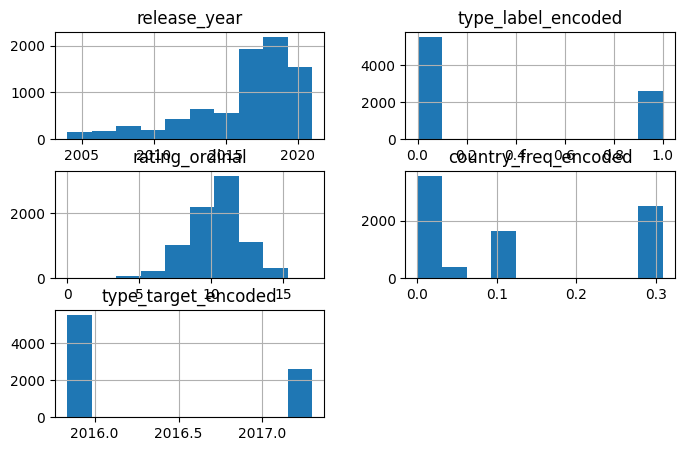

In [35]:
df[numeric_cols].hist(figsize=(8,5))
plt.show()

Transform Skewed Features (Log Transformation)

In [36]:
import numpy as np


In [37]:
# Apply log transformation
df['release_year_log'] = np.log1p(df['release_year'])
df[['release_year','release_year_log']].head()

,release_year,release_year_log
0,2020,7.611348
1,2021,7.611842
2,2021,7.611842
3,2021,7.611842
4,2021,7.611842


Verify Skewness After Transformation

In [38]:
print("Skewness after log transformation:")
print(df['release_year_log'].skew())

Skewness after log transformation:
-1.1983568393192332


Train/Test Split

In [39]:
from sklearn.model_selection import train_test_split

In [40]:
# Define features and target
X = df.drop('release_year_log', axis=1)
y = df['release_year_log']

In [41]:
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [42]:
print("Training data shape:", X_train.shape)
print("Testing data shape:", X_test.shape)

Training data shape: (6470, 14)
Testing data shape: (1618, 14)
